<a href="https://colab.research.google.com/github/sergio1/estudos/blob/main/aula_7_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

dados_producao_vacinas = {
    'data': ['2025-05-01', '2025-05-01', '2025-05-02', '2025-05-02', '2025-05-03'],
    'turno': ['Manhã', 'Tarde', 'Manhã', 'Tarde', 'Manhã'],
    'temperatura_reator': [75.2, 76.1, 74.9, 75.5, 76.0],
    'concentracao_reagente': [0.98, 0.97, 0.99, 0.98, 0.97],
    'pureza_final': [99.5, 98.8, 99.7, 99.0, 99.2]
}

df_vacinas = pd.DataFrame(dados_producao_vacinas)
print(df_vacinas)

         data  turno  temperatura_reator  concentracao_reagente  pureza_final
0  2025-05-01  Manhã                75.2                   0.98          99.5
1  2025-05-01  Tarde                76.1                   0.97          98.8
2  2025-05-02  Manhã                74.9                   0.99          99.7
3  2025-05-02  Tarde                75.5                   0.98          99.0
4  2025-05-03  Manhã                76.0                   0.97          99.2


In [3]:
# Exemplo de padronização da coluna 'turno'
df_vacinas['turno'] = df_vacinas['turno'].str.capitalize() # Converte a primeira letra para maiúscula e o restante para minúscula
print("\nDataFrame após padronização de turno:")
print(df_vacinas)


DataFrame após padronização de turno:
         data  turno  temperatura_reator  concentracao_reagente  pureza_final
0  2025-05-01  Manhã                75.2                   0.98          99.5
1  2025-05-01  Tarde                76.1                   0.97          98.8
2  2025-05-02  Manhã                74.9                   0.99          99.7
3  2025-05-02  Tarde                75.5                   0.98          99.0
4  2025-05-03  Manhã                76.0                   0.97          99.2


In [4]:
# Supondo que tivéssemos valores nulos na coluna 'temperatura_reator'
# df_vacinas.loc[0, 'temperatura_reator'] = None # Simula um valor nulo

media_temperatura = df_vacinas['temperatura_reator'].mean()
df_vacinas['temperatura_reator'] = df_vacinas['temperatura_reator'].fillna(media_temperatura)
print("\nDataFrame após preenchimento de valores nulos na temperatura do reator:")
print(df_vacinas)


DataFrame após preenchimento de valores nulos na temperatura do reator:
         data  turno  temperatura_reator  concentracao_reagente  pureza_final
0  2025-05-01  Manhã                75.2                   0.98          99.5
1  2025-05-01  Tarde                76.1                   0.97          98.8
2  2025-05-02  Manhã                74.9                   0.99          99.7
3  2025-05-02  Tarde                75.5                   0.98          99.0
4  2025-05-03  Manhã                76.0                   0.97          99.2


In [8]:
print("\nEstatísticas descritivas para a pureza final:")
print(df_vacinas['pureza_final'].describe())

print("\nDesvio padrão da temperatura do reator:")
print(df_vacinas['temperatura_reator'].std())

print(df_vacinas['temperatura_reator'].info())


Estatísticas descritivas para a pureza final:
count     5.000000
mean     99.240000
std       0.364692
min      98.800000
25%      99.000000
50%      99.200000
75%      99.500000
max      99.700000
Name: pureza_final, dtype: float64

Desvio padrão da temperatura do reator:
0.5128352561983196
<class 'pandas.core.series.Series'>
RangeIndex: 5 entries, 0 to 4
Series name: temperatura_reator
Non-Null Count  Dtype  
--------------  -----  
5 non-null      float64
dtypes: float64(1)
memory usage: 172.0 bytes
None


In [9]:
print(df_vacinas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   data                   5 non-null      object 
 1   turno                  5 non-null      object 
 2   temperatura_reator     5 non-null      float64
 3   concentracao_reagente  5 non-null      float64
 4   pureza_final           5 non-null      float64
dtypes: float64(3), object(2)
memory usage: 332.0+ bytes
None


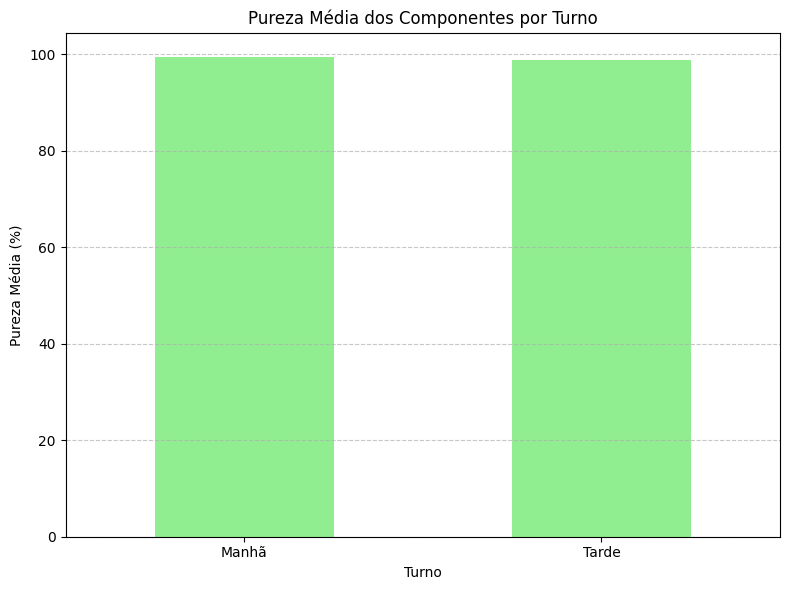

In [6]:
import matplotlib.pyplot as plt

media_pureza_por_turno = df_vacinas.groupby('turno')['pureza_final'].mean()

plt.figure(figsize=(8, 6))
media_pureza_por_turno.plot(kind='bar', color='lightgreen')
plt.title('Pureza Média dos Componentes por Turno')
plt.xlabel('Turno')
plt.ylabel('Pureza Média (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3228714470.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_pureza_por_turno.index, y=media_pureza_por_turno.values, palette="pastel")


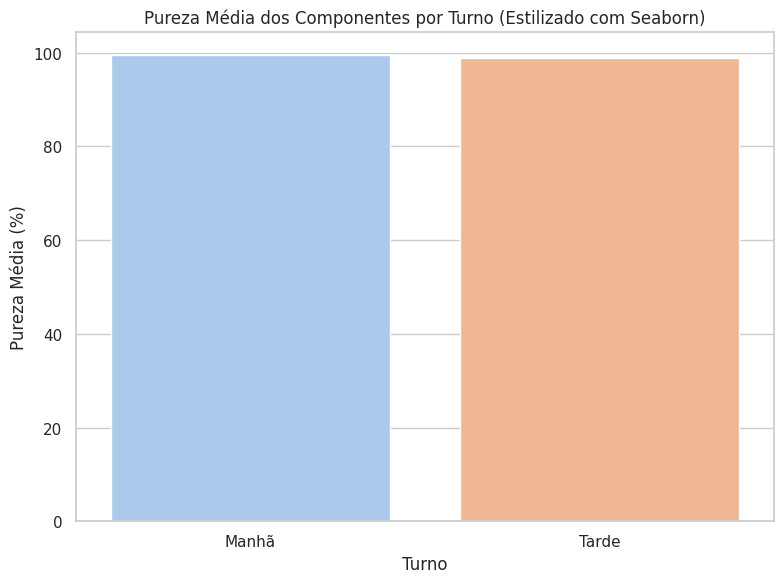

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid") # Define um estilo de tema para o Seaborn

plt.figure(figsize=(8, 6))
sns.barplot(x=media_pureza_por_turno.index, y=media_pureza_por_turno.values, palette="pastel")
plt.title('Pureza Média dos Componentes por Turno (Estilizado com Seaborn)')
plt.xlabel('Turno')
plt.ylabel('Pureza Média (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()